# TransFlower: Commuting Flow Prediction

Реализация модели **TransFlower** из статьи:
> *TransFlower: An Explainable Transformer-Based Model with Flow-to-Flow Attention for Commuting Flow Prediction*

Данные: [CommutingODGen-Dataset](https://github.com/tsinghua-fib-lab/CommutingODGen-Dataset)

## Архитектура
1. **Geo-Spatial Encoder** — кодирует признаки каждого потока (origin + destination features + distance)
2. **Relative Location Encoder (RLE)** — Space2Vec-подобное кодирование направления и расстояния
3. **Transformer Flow Predictor** — self-attention между потоками из одного origin
4. **Prediction Head** — softmax для распределения вероятностей по destination

## 1. Установка зависимостей

In [ ]:
!pip install torch scikit-learn scipy geopandas matplotlib seaborn -q
!git clone https://github.com/tsinghua-fib-lab/CommutingODGen-Dataset.git

fatal: destination path 'CommutingODGen-Dataset' already exists and is not an empty directory.


## 2. Импорты и конфигурация

In [ ]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import MinMaxScaler

# ── Пути к данным ──────────────────────────────────────────────
DATA_PATH = "/content/CommutingODGen-Dataset/data"
SHP_PATH  = "/content/CommutingODGen-Dataset/assets/Boundaries_Regions_within_Areas"

# ── Один город для обучения ────────────────────────────────────
# 17031 = Cook County (Chicago), 06037 = Los Angeles, 25025 = Suffolk (Boston)
SINGLE_CITY = "48201"

# ── Гиперпараметры модели ──────────────────────────────────────
HIDDEN_DIM    = 256    # размерность скрытых слоёв
N_HEADS       = 4      # количество голов в multi-head attention
N_LAYERS      = 2      # количество слоёв трансформера
DROPOUT       = 0.1

# ── RLE параметры (из статьи) ──────────────────────────────────
RLE_FREQ       = 16       # количество частот
RLE_LAMBDA_MIN = 1.0      # минимальный масштаб
RLE_LAMBDA_MAX = 20000.0  # максимальный масштаб (диаметр региона в метрах)
RLE_OUT_DIM    = 64       # выходная размерность RLE

# ── Параметры обучения ─────────────────────────────────────────
N_DESTINATIONS = 128   # число destination на один origin (статья: 256, уменьшено для скорости)
EPOCHS         = 50
LR             = 1e-4
PATIENCE       = 10
BATCH_SIZE     = 32    # количество origin-регионов в батче

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 3. Загрузка данных

In [ ]:
import geopandas as gpd

def precompute_coords(data_path, shp_base_path):
    """Вычислить центроиды регионов из shapefiles (запускается один раз)."""
    saved = 0
    for area_id in os.listdir(data_path):
        area_dir = os.path.join(data_path, area_id)
        if not os.path.isdir(area_dir):
            continue
        coords_path = os.path.join(area_dir, "coords.npy")
        if os.path.exists(coords_path):
            continue
        shp_file = os.path.join(shp_base_path, area_id, f"{area_id}.shp")
        if not os.path.exists(shp_file):
            continue
        try:
            gdf = gpd.read_file(shp_file)
            projected = gdf.to_crs("EPSG:3857")
            centroids = projected.geometry.centroid
            coords = np.column_stack([centroids.x.values, centroids.y.values])
            np.save(coords_path, coords)
            saved += 1
        except Exception as e:
            pass
    print(f"Координаты вычислены для {saved} новых регионов")


def load_area(area_id):
    """Загрузить данные одного региона.
    Возвращает: nfeat (N, F), adj (N, N), dis (N, N), od (N, N), coords (N, 2) или None
    """
    path = os.path.join(DATA_PATH, area_id)
    try:
        demos = np.load(os.path.join(path, "demos.npy"))   # демография
        pois  = np.load(os.path.join(path, "pois.npy"))    # POI
        adj   = np.load(os.path.join(path, "adj.npy"))     # матрица смежности
        dis   = np.load(os.path.join(path, "dis.npy"))     # расстояния
        od    = np.load(os.path.join(path, "od.npy"))      # OD матрица (целевая)
        nfeat = np.concatenate([demos, pois], axis=1)      # объединяем признаки

        coords_path = os.path.join(path, "coords.npy")
        coords = np.load(coords_path) if os.path.exists(coords_path) else None
        return nfeat, adj, dis, od, coords
    except Exception as e:
        print(f"Ошибка загрузки {area_id}: {e}")
        return None


# Запускаем предвычисление координат
precompute_coords(DATA_PATH, SHP_PATH)

# Загружаем данные города
data = load_area(SINGLE_CITY)
assert data is not None, f"Не удалось загрузить {SINGLE_CITY}"

nfeat, adj, dis, od, coords = data
N = nfeat.shape[0]
FEAT_DIM = nfeat.shape[1]

print(f"Город: {SINGLE_CITY}")
print(f"  Регионов (N):        {N}")
print(f"  Признаков (F):       {FEAT_DIM}")
print(f"  OD матрица:          {od.shape}")
print(f"  Ненулевых потоков:   {(od > 0).sum():,}")
print(f"  Всего коммутирующих: {od.sum():,.0f}")
print(f"  Координаты:          {'есть' if coords is not None else 'нет'}")

Координаты вычислены для 0 новых регионов
Город: 48201
  Регионов (N):        786
  Признаков (F):       131
  OD матрица:          (786, 786)
  Ненулевых потоков:   286,923
  Всего коммутирующих: 1,585,214
  Координаты:          есть


## 4. Подготовка данных

In [ ]:
# Масштабирование признаков
nfeat_scaler = MinMaxScaler()
dis_scaler   = MinMaxScaler()

nfeat_scaled = nfeat_scaler.fit_transform(nfeat)           # (N, F) → [0, 1]
dis_scaled   = dis_scaler.fit_transform(dis.reshape(-1, 1)).reshape(N, N)

# Вычисляем outflow для каждого origin (суммарные исходящие потоки)
outflow = od.sum(axis=1)  # (N,)

# Разбивка origins на train/val/test (80/10/10)
np.random.seed(42)
origin_ids = np.arange(N)
np.random.shuffle(origin_ids)

n_train = int(N * 0.8)
n_val   = int(N * 0.9)

train_origins = origin_ids[:n_train]
val_origins   = origin_ids[n_train:n_val]
test_origins  = origin_ids[n_val:]

print(f"Разбивка origins: train={len(train_origins)}, val={len(val_origins)}, test={len(test_origins)}")

# Преобразуем в тензоры
nfeat_t  = torch.FloatTensor(nfeat_scaled).to(device)   # (N, F)
dis_t    = torch.FloatTensor(dis_scaled).to(device)      # (N, N)
coords_t = torch.FloatTensor(coords).to(device) if coords is not None else None  # (N, 2)

Разбивка origins: train=628, val=79, test=79


## 5. Модель TransFlower

In [ ]:
class RelativeLocationEncoder(nn.Module):
    """
    RLE: кодирует относительное положение (origin - destination) в векторное пространство.
    Использует многомасштабные sinusoidal функции — Space2Vec из статьи.
    Два набора базисных векторов (RLE вариант из статьи) для устранения гексагонального артефакта.
    """
    def __init__(self, freq=16, lambda_min=1.0, lambda_max=20000.0, out_dim=64):
        super().__init__()
        self.freq = freq
        self.lambda_min = lambda_min
        self.lambda_max = lambda_max

        # Базисные векторы: 3 вектора под углом 2π/3 — первый набор
        angles1 = [0, 2 * np.pi / 3, 4 * np.pi / 3]
        self.basis1 = torch.FloatTensor(
            [[np.cos(a), np.sin(a)] for a in angles1]
        )  # (3, 2)

        # Второй набор — повёрнут на π/6 для устранения гексагонального артефакта
        angles2 = [a + np.pi / 6 for a in angles1]
        self.basis2 = torch.FloatTensor(
            [[np.cos(a), np.sin(a)] for a in angles2]
        )  # (3, 2)

        # Логарифмически равномерно распределённые масштабы
        g = lambda_max / lambda_min
        self.scales = torch.FloatTensor(
            [lambda_min * (g ** (s / (freq - 1))) for s in range(freq)]
        )  # (freq,)

        # Размерность входа в FF: 2 набора × 3 вектора × freq × 2 (sin/cos) = 12*freq
        pe_dim = 2 * 3 * freq * 2
        self.ff = nn.Sequential(
            nn.Linear(pe_dim, out_dim * 2),
            nn.ReLU(),
            nn.Linear(out_dim * 2, out_dim)
        )

    def _encode_basis(self, rel_loc, basis):
        """Кодирует rel_loc через набор базисных векторов."""
        # rel_loc: (B, 2), basis: (3, 2), scales: (freq,)
        basis = basis.to(rel_loc.device)       # (3, 2)
        scales = self.scales.to(rel_loc.device) # (freq,)

        # Проекции: (B, 3)
        proj = rel_loc @ basis.T  # (B, 3)

        # Многомасштабное кодирование: (B, 3, freq)
        proj_scaled = proj.unsqueeze(2) / scales.view(1, 1, -1)  # (B, 3, freq)

        # sin и cos: (B, 3, freq, 2)
        pe = torch.stack([torch.cos(proj_scaled), torch.sin(proj_scaled)], dim=-1)
        return pe.reshape(rel_loc.shape[0], -1)  # (B, 3*freq*2)

    def forward(self, rel_loc):
        """rel_loc: (B, 2) — вектор (coord_origin - coord_destination)"""
        pe1 = self._encode_basis(rel_loc, self.basis1)  # (B, 3*freq*2)
        pe2 = self._encode_basis(rel_loc, self.basis2)  # (B, 3*freq*2)
        pe  = torch.cat([pe1, pe2], dim=-1)              # (B, 6*freq*2)
        return self.ff(pe)                               # (B, out_dim)


class GeoSpatialEncoder(nn.Module):
    """
    Кодирует каждый поток (origin_features + destination_features + distance) → embedding.
    Соответствует Geographic Feature Encoder из статьи.
    """
    def __init__(self, feat_dim, hidden_dim=256):
        super().__init__()
        # Вход: признаки origin + destination + расстояние = feat_dim*2 + 1
        self.ff = nn.Sequential(
            nn.Linear(feat_dim * 2 + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, feat_o, feat_d, dist):
        """
        feat_o, feat_d: (B, F) — признаки origin и destination
        dist:           (B, 1) — нормализованное расстояние
        """
        x = torch.cat([feat_o, feat_d, dist], dim=-1)  # (B, 2F+1)
        return self.ff(x)                               # (B, hidden_dim)


class TransFlower(nn.Module):
    """
    Полная модель TransFlower.

    Для каждого origin:
      1. GeoSpatialEncoder кодирует каждый поток (origin→dest_i)
      2. RLE добавляет пространственное направление
      3. Transformer Encoder обрабатывает взаимодействия между потоками
      4. Prediction Head → softmax → вероятности назначения
    """
    def __init__(self,
                 feat_dim,
                 hidden_dim=256,
                 n_heads=4,
                 n_layers=2,
                 dropout=0.1,
                 rle_out_dim=64,
                 rle_freq=16,
                 rle_lambda_min=1.0,
                 rle_lambda_max=20000.0,
                 use_rle=True):
        super().__init__()
        self.use_rle = use_rle

        # Geo-Spatial Encoder
        self.geo_encoder = GeoSpatialEncoder(feat_dim, hidden_dim)

        # Relative Location Encoder (опциональный)
        if use_rle:
            self.rle = RelativeLocationEncoder(
                freq=rle_freq,
                lambda_min=rle_lambda_min,
                lambda_max=rle_lambda_max,
                out_dim=rle_out_dim
            )
            flow_emb_dim = hidden_dim + rle_out_dim
        else:
            self.rle = None
            flow_emb_dim = hidden_dim

        # Проекция в размерность трансформера (должна делиться на n_heads)
        # Округляем до ближайшего кратного n_heads
        tf_dim = ((flow_emb_dim + n_heads - 1) // n_heads) * n_heads
        self.proj = nn.Linear(flow_emb_dim, tf_dim)

        # Transformer Encoder — моделирует взаимодействия между потоками
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=tf_dim,
            nhead=n_heads,
            dim_feedforward=tf_dim * 4,
            dropout=dropout,
            batch_first=True  # (B, seq, dim)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Prediction Head → скаляр для каждого destination
        self.pred_head = nn.Sequential(
            nn.Linear(tf_dim, tf_dim // 2),
            nn.ReLU(),
            nn.Linear(tf_dim // 2, 1)
        )

    def forward(self, nfeat, dis, dest_ids, origin_id, coords=None):
        """
        Предсказывает вероятности destination для одного origin.

        nfeat:     (N, F) — признаки всех регионов
        dis:       (N, N) — матрица расстояний
        dest_ids:  (D,)   — индексы D destination регионов
        origin_id: int    — индекс origin региона
        coords:    (N, 2) — координаты регионов (для RLE)

        Возвращает:
          probs:   (D,)   — вероятности (sum=1)
          attn_w:  None   (можно добавить извлечение attention весов)
        """
        D = len(dest_ids)

        feat_o = nfeat[origin_id].unsqueeze(0).expand(D, -1)  # (D, F)
        feat_d = nfeat[dest_ids]                               # (D, F)
        dist   = dis[origin_id, dest_ids].unsqueeze(-1)        # (D, 1)

        # 1. Geographic Feature Encoder
        flow_emb = self.geo_encoder(feat_o, feat_d, dist)  # (D, hidden_dim)

        # 2. Relative Location Encoder
        if self.use_rle and coords is not None:
            rel_loc = coords[origin_id].unsqueeze(0) - coords[dest_ids]  # (D, 2)
            rle_emb = self.rle(rel_loc)                                   # (D, rle_out_dim)
            flow_emb = torch.cat([flow_emb, rle_emb], dim=-1)            # (D, hidden+rle)

        # 3. Проекция + Transformer (обрабатываем как последовательность из D потоков)
        flow_emb = self.proj(flow_emb)             # (D, tf_dim)
        flow_emb = flow_emb.unsqueeze(0)           # (1, D, tf_dim) — batch_first
        tf_out   = self.transformer(flow_emb)      # (1, D, tf_dim)
        tf_out   = tf_out.squeeze(0)               # (D, tf_dim)

        # 4. Prediction Head + Softmax
        scores = self.pred_head(tf_out).squeeze(-1)  # (D,)
        probs  = F.softmax(scores, dim=0)             # (D,) — сумма = 1

        return probs

## 6. Функции обучения и оценки

In [ ]:
def sample_destinations(origin_id, od_matrix, n_dest=128):
    """
    Выбираем N_DESTINATIONS destination для заданного origin.
    Если destinations < n_dest — берём все (без padding, как упрощение).
    """
    N = od_matrix.shape[0]
    # Все возможные destinations (кроме self-loop)
    all_dests = np.array([j for j in range(N) if j != origin_id])

    if len(all_dests) <= n_dest:
        return all_dests

    # Случайная выборка (из статьи: random sampling если > 256)
    return np.random.choice(all_dests, size=n_dest, replace=False)


def compute_loss(model, origins, nfeat_t, dis_t, od, outflow,
                 coords_t, n_dest=128):
    """
    Cross-entropy loss по нескольким origin-регионам.
    Loss = -sum_i sum_j (true_ratio_ij * log(pred_prob_ij))
    """
    total_loss = 0.0
    count = 0

    for oi in origins:
        O_i = outflow[oi]
        if O_i < 1:
            continue  # пропускаем regions без исходящих потоков

        dest_ids = sample_destinations(oi, od, n_dest)
        dest_t   = torch.LongTensor(dest_ids).to(device)

        # Предсказанные вероятности
        probs = model(nfeat_t, dis_t, dest_t, oi, coords_t)  # (D,)

        # Истинные доли (true_ratio = flow_ij / total_outflow_i)
        true_flows  = torch.FloatTensor(od[oi, dest_ids]).to(device)  # (D,)
        true_ratios = true_flows / (O_i + 1e-8)                       # (D,)

        # Cross-entropy: -sum(ratio * log(prob))
        loss = -torch.sum(true_ratios * torch.log(probs + 1e-10))
        total_loss += loss
        count += 1

    return total_loss / max(count, 1)


def predict_od(model, origins, nfeat_t, dis_t, od, outflow, coords_t, N):
    """Предсказать полную OD матрицу для заданных origins."""
    model.eval()
    pred_od = np.zeros((len(origins), N), dtype=np.float32)

    with torch.no_grad():
        for idx, oi in enumerate(origins):
            O_i = outflow[oi]
            if O_i < 1:
                continue

            # Для оценки берём все destinations
            dest_ids = np.array([j for j in range(N) if j != oi])
            dest_t   = torch.LongTensor(dest_ids).to(device)

            probs = model(nfeat_t, dis_t, dest_t, oi, coords_t).cpu().numpy()

            # Реальные потоки = вероятности × outflow
            pred_row = np.zeros(N)
            pred_row[dest_ids] = probs * O_i
            pred_od[idx] = pred_row

    return pred_od


# ── Метрики ────────────────────────────────────────────────────
def cpc(pred, true):
    """Common Part of Commuters — основная метрика из статьи."""
    return 2 * np.minimum(pred, true).sum() / (pred.sum() + true.sum() + 1e-10)

def mae(pred, true):
    return np.abs(pred - true).mean()

def rmse(pred, true):
    return np.sqrt(((pred - true) ** 2).mean())

def compute_metrics(pred, true):
    return {
        'CPC':  cpc(pred, true),
        'MAE':  mae(pred, true),
        'RMSE': rmse(pred, true)
    }

## 7. Обучение

In [ ]:
# Инициализация модели
model = TransFlower(
    feat_dim      = FEAT_DIM,
    hidden_dim    = HIDDEN_DIM,
    n_heads       = N_HEADS,
    n_layers      = N_LAYERS,
    dropout       = DROPOUT,
    rle_out_dim   = RLE_OUT_DIM,
    rle_freq      = RLE_FREQ,
    rle_lambda_min= RLE_LAMBDA_MIN,
    rle_lambda_max= RLE_LAMBDA_MAX,
    use_rle       = (coords is not None)
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров модели: {n_params:,}")
print(model)

optimizer = torch.optim.RMSprop(model.parameters(), lr=LR, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

Параметров модели: 2,786,497
TransFlower(
  (geo_encoder): GeoSpatialEncoder(
    (ff): Sequential(
      (0): Linear(in_features=263, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (rle): RelativeLocationEncoder(
    (ff): Sequential(
      (0): Linear(in_features=192, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (proj): Linear(in_features=320, out_features=320, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=320, out_features=320, bias=True)
        )
        (linear1): Linear(in_features=320, out_features=1280, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1280, out_features=320, bias=True)
        (norm1): La

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'val_cpc': []}
best_val_loss = float('inf')
patience_cnt  = 0
best_state    = None

print(f"\nНачало обучения | Epochs={EPOCHS} | Origins train={len(train_origins)}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()

    # Перемешиваем train origins каждую эпоху
    shuffled = train_origins.copy()
    np.random.shuffle(shuffled)

    # Батчевое обучение
    epoch_loss = 0.0
    n_batches  = 0
    for start in range(0, len(shuffled), BATCH_SIZE):
        batch = shuffled[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        loss = compute_loss(model, batch, nfeat_t, dis_t, od, outflow,
                            coords_t, N_DESTINATIONS)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    train_loss = epoch_loss / max(n_batches, 1)

    # Валидация
    model.eval()
    with torch.no_grad():
        val_loss = compute_loss(model, val_origins, nfeat_t, dis_t, od, outflow,
                                coords_t, N_DESTINATIONS).item()

    # CPC на val (быстрая оценка на подмножестве)
    sample_origins = val_origins[:min(20, len(val_origins))]
    pred_sample = predict_od(model, sample_origins, nfeat_t, dis_t, od, outflow, coords_t, N)
    true_sample = od[sample_origins]
    val_cpc = cpc(pred_sample, true_sample)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cpc'].append(val_cpc)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
        flag = " ✓ best"
    else:
        patience_cnt += 1
        flag = ""

    elapsed = time.time() - t0
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"train={train_loss:.4f} | val={val_loss:.4f} | "
              f"CPC={val_cpc:.4f} | {elapsed:.1f}s{flag}")

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping на epoch {epoch}")
        break

# Восстанавливаем лучшие веса
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nЛучшие веса восстановлены (val_loss={best_val_loss:.4f})")


Начало обучения | Epochs=50 | Origins train=628
------------------------------------------------------------
Epoch   1/50 | train=0.7705 | val=0.7585 | CPC=0.3881 | 9.7s ✓ best
Epoch   5/50 | train=0.6590 | val=0.6469 | CPC=0.5301 | 4.8s ✓ best
Epoch  10/50 | train=0.6370 | val=0.6462 | CPC=0.6112 | 4.1s
Epoch  15/50 | train=0.6081 | val=0.5882 | CPC=0.6458 | 4.2s
Epoch  20/50 | train=0.6035 | val=0.5839 | CPC=0.6789 | 5.1s
Epoch  25/50 | train=0.5951 | val=0.5910 | CPC=0.6859 | 4.1s
Epoch  30/50 | train=0.5929 | val=0.5809 | CPC=0.6979 | 4.7s
Epoch  35/50 | train=0.5942 | val=0.6007 | CPC=0.7043 | 4.8s

Early stopping на epoch 38

Лучшие веса восстановлены (val_loss=0.5556)


## 8. Визуализация процесса обучения

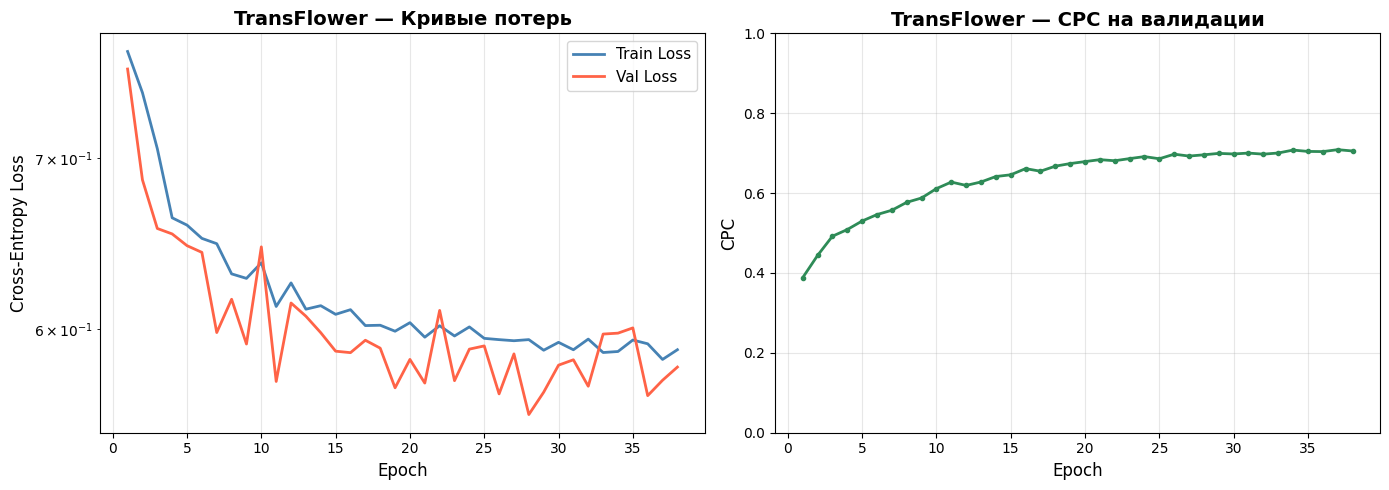

Лучший CPC на val: 0.7087


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# График потерь
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
ax.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('TransFlower — Кривые потерь', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# График CPC
ax = axes[1]
ax.plot(epochs_range, history['val_cpc'], color='seagreen', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('CPC', fontsize=12)
ax.set_title('TransFlower — CPC на валидации', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Лучший CPC на val: {max(history['val_cpc']):.4f}")

## 9. Оценка на тестовой выборке

In [ ]:
print("Оценка на тестовой выборке...")

pred_test = predict_od(model, test_origins, nfeat_t, dis_t, od, outflow, coords_t, N)
true_test = od[test_origins].astype(float)

metrics = compute_metrics(pred_test.ravel(), true_test.ravel())

print("\n" + "=" * 40)
print("  РЕЗУЛЬТАТЫ НА ТЕСТЕ")
print("=" * 40)
for k, v in metrics.items():
    print(f"  {k:6s}: {v:.4f}")
print("=" * 40)

Оценка на тестовой выборке...

  РЕЗУЛЬТАТЫ НА ТЕСТЕ
  CPC   : 0.6836
  MAE   : 1.7382
  RMSE  : 6.1438


## 10. Визуализация предсказаний

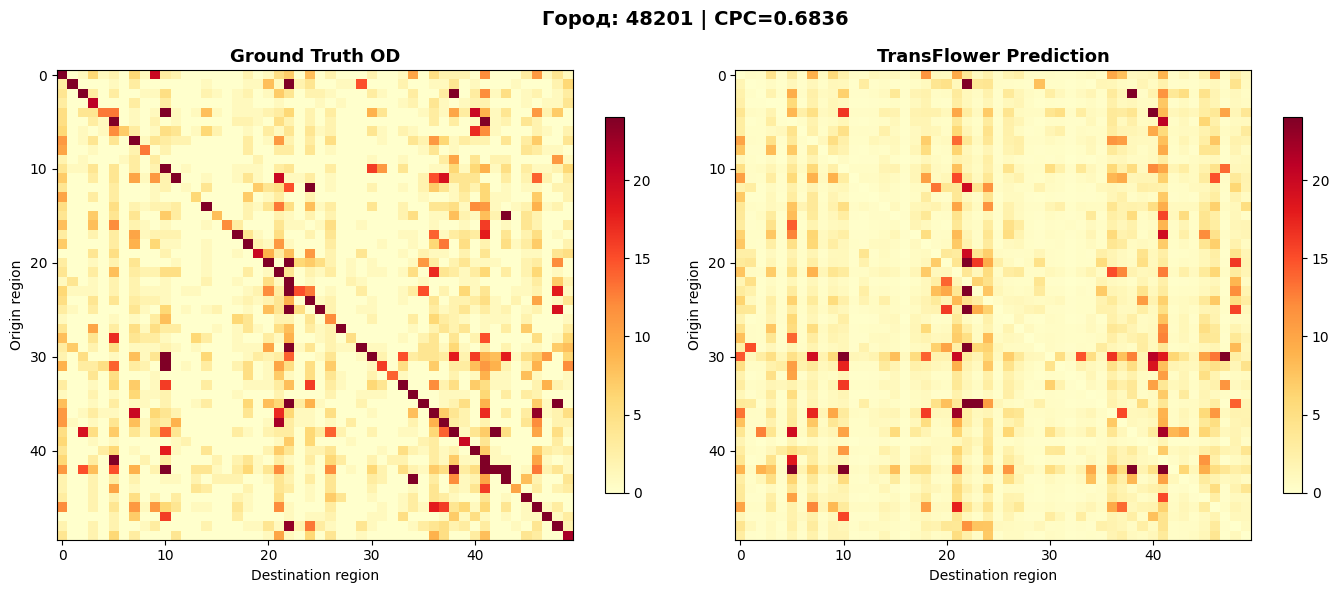

In [ ]:
# ── Тепловые карты OD матрицы ──────────────────────────────────
# Берём первые 50 origins для наглядности
vis_origins = test_origins[:50]
pred_vis = predict_od(model, vis_origins, nfeat_t, dis_t, od, outflow, coords_t, N)
true_vis = od[vis_origins, :].astype(float)

# Берём подматрицу (vis_origins × vis_origins) для отображения
vis_idx   = vis_origins
pred_sub  = pred_vis[:, vis_idx]   # (50, 50)
true_sub  = true_vis[:, vis_idx]   # (50, 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmax = np.percentile(true_sub, 98)

im0 = axes[0].imshow(true_sub, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')
axes[0].set_title('Ground Truth OD', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Destination region')
axes[0].set_ylabel('Origin region')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(pred_sub, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')
axes[1].set_title('TransFlower Prediction', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Destination region')
axes[1].set_ylabel('Origin region')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle(f'Город: {SINGLE_CITY} | CPC={metrics["CPC"]:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/od_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

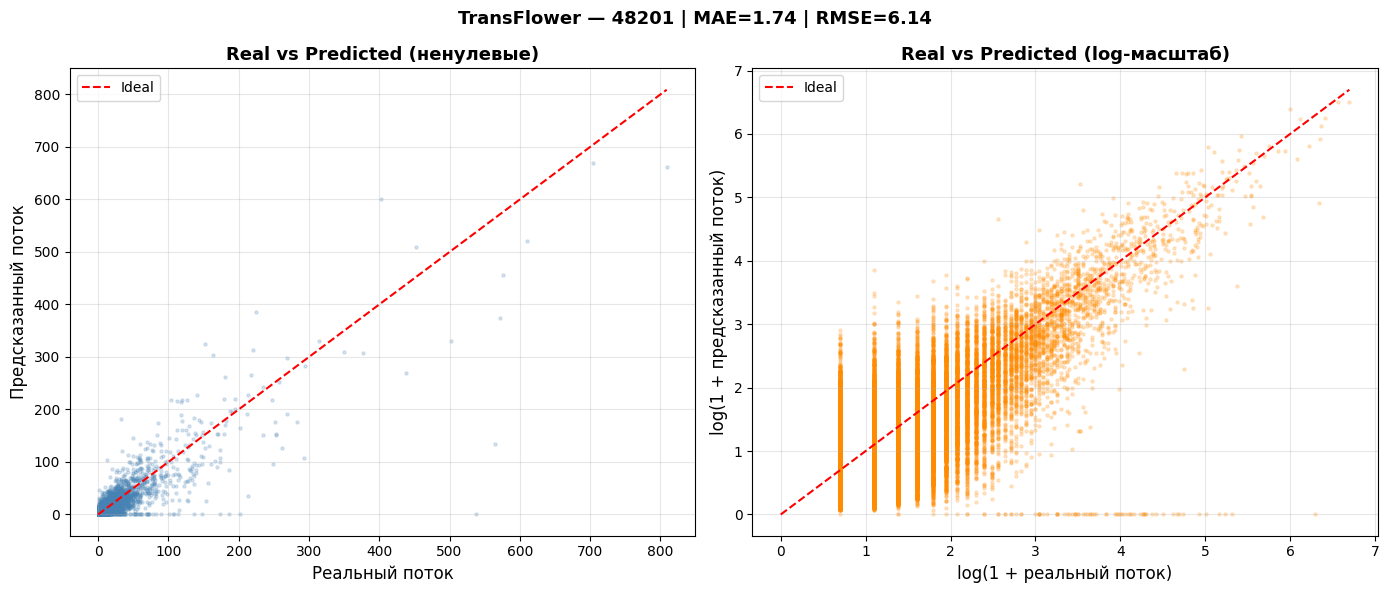

In [ ]:
# ── Scatter plot: реальные vs предсказанные потоки ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

true_flat = true_test.ravel()
pred_flat = pred_test.ravel()

# Показываем только ненулевые потоки
mask = true_flat > 0
t, p = true_flat[mask], pred_flat[mask]

ax = axes[0]
ax.scatter(t, p, alpha=0.2, s=5, color='steelblue', rasterized=True)
lim = max(t.max(), p.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('Реальный поток', fontsize=12)
ax.set_ylabel('Предсказанный поток', fontsize=12)
ax.set_title('Real vs Predicted (ненулевые)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# В лог-масштабе
ax = axes[1]
ax.scatter(np.log1p(t), np.log1p(p), alpha=0.2, s=5, color='darkorange', rasterized=True)
lim = max(np.log1p(t).max(), np.log1p(p).max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('log(1 + реальный поток)', fontsize=12)
ax.set_ylabel('log(1 + предсказанный поток)', fontsize=12)
ax.set_title('Real vs Predicted (log-масштаб)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'TransFlower — {SINGLE_CITY} | MAE={metrics["MAE"]:.2f} | RMSE={metrics["RMSE"]:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4560/2736281558.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/flow_map_shp.png'

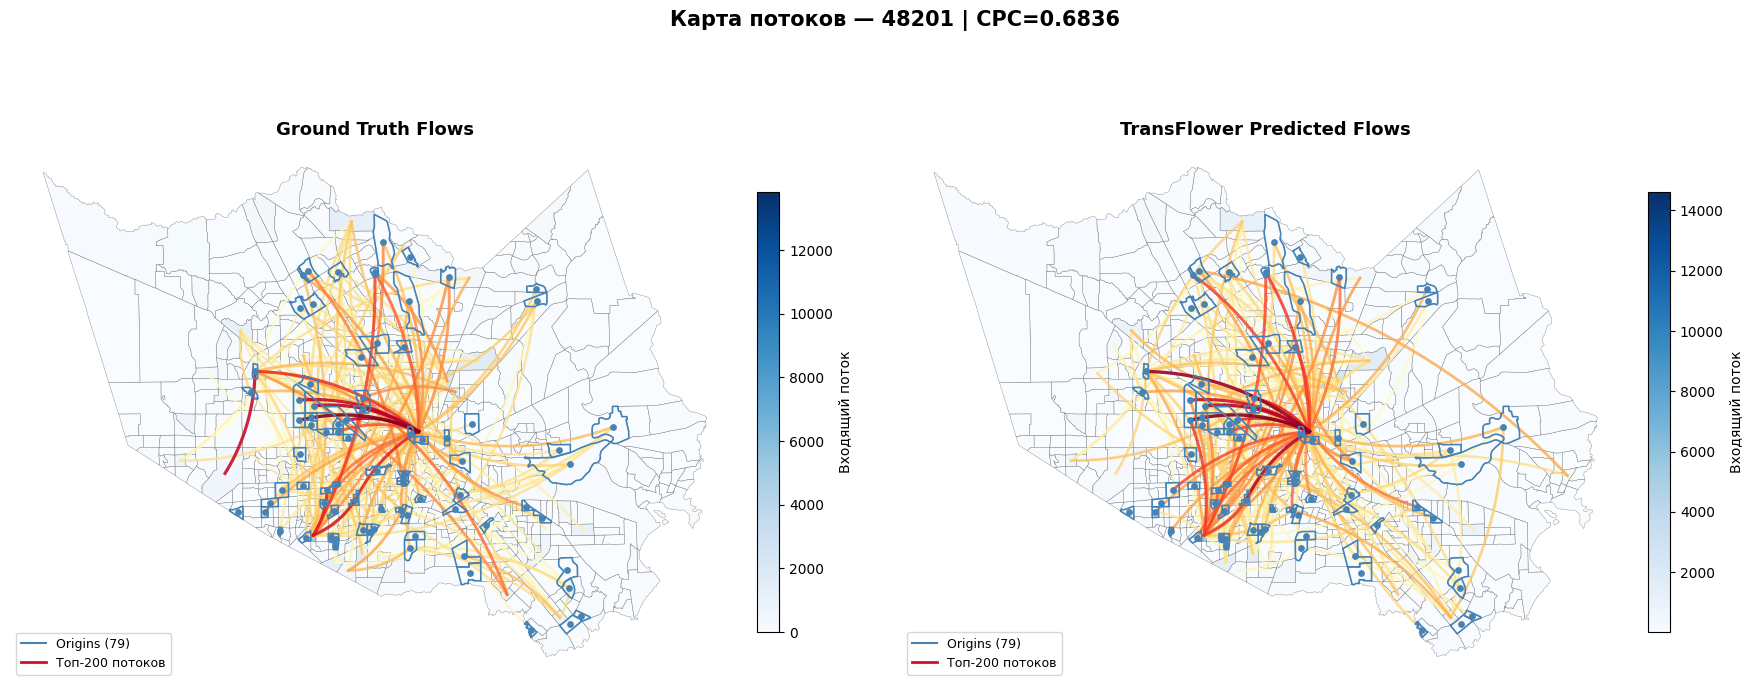

In [ ]:
# ── Flow map по shp файлам ─────────────────────────────────────
import geopandas as gpd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

shp_file = os.path.join(SHP_PATH, SINGLE_CITY, f"{SINGLE_CITY}.shp")

if os.path.exists(shp_file):
    # Загружаем shapefile и проецируем в WGS84 для отображения
    gdf = gpd.read_file(shp_file).to_crs("EPSG:4326")

    # Центроиды для рисования потоков
    centroids = gdf.geometry.centroid
    lons = centroids.x.values
    lats = centroids.y.values

    def draw_flowmap_shp(ax, od_matrix, origins, title, top_k=200):
        """
        Рисует потоки поверх shapefile-полигонов регионов.
        od_matrix: (len(origins), N) — строки соответствуют origins
        """
        # 1. Базовая карта — полигоны регионов, залитые суммарным потоком
        inflow = od_matrix.sum(axis=0)          # (N,) — входящий поток в каждый регион
        gdf_plot = gdf.copy()
        gdf_plot['inflow'] = inflow

        gdf_plot.plot(
            ax=ax,
            column='inflow',
            cmap='Blues',
            linewidth=0.3,
            edgecolor='#555',
            alpha=0.7,
            legend=True,
            legend_kwds={
                'label': 'Входящий поток',
                'shrink': 0.6,
                'pad': 0.02
            }
        )

        # 2. Выделяем origin-регионы контуром
        gdf.iloc[origins].plot(
            ax=ax,
            facecolor='none',
            edgecolor='steelblue',
            linewidth=1.2,
            zorder=4
        )

        # 3. Топ-K потоков в виде кривых
        flat = od_matrix.ravel()
        if len(flat) == 0:
            ax.set_title(title, fontsize=13, fontweight='bold')
            return

        k = min(top_k, (flat > 0).sum())
        if k == 0:
            ax.set_title(title, fontsize=13, fontweight='bold')
            return

        threshold = np.sort(flat)[-k]
        threshold = max(threshold, 1)

        # oi_idx — индекс в origins[], oj_idx — индекс региона-destination
        oi_idx, oj_idx = np.where(od_matrix >= threshold)
        flows = od_matrix[oi_idx, oj_idx]

        log_flows = np.log1p(flows)
        log_max   = log_flows.max() + 1e-10
        norm = mcolors.Normalize(vmin=log_flows.min(), vmax=log_flows.max())
        cmap = plt.cm.YlOrRd

        # Рисуем от слабых к сильным (сильные поверх)
        for idx in np.argsort(flows):
            row_i = oi_idx[idx]          # индекс в срезе origins
            col_j = oj_idx[idx]          # индекс региона-destination

            real_origin = origins[row_i] # реальный индекс региона-origin
            x0, y0 = lons[real_origin], lats[real_origin]
            x1, y1 = lons[col_j],       lats[col_j]

            # Кубическая кривая Безье для красоты
            mx, my   = (x0 + x1) / 2, (y0 + y1) / 2
            dx, dy   = x1 - x0, y1 - y0
            cx, cy   = mx - 0.15 * dy, my + 0.15 * dx
            t        = np.linspace(0, 1, 30)
            bx = (1-t)**2 * x0 + 2*(1-t)*t * cx + t**2 * x1
            by = (1-t)**2 * y0 + 2*(1-t)*t * cy + t**2 * y1

            color = cmap(norm(log_flows[idx]))
            lw    = 0.4 + 2.0 * (log_flows[idx] / log_max)
            alpha = min(0.3 + 0.6 * (log_flows[idx] / log_max), 0.9)
            ax.plot(bx, by, color=color, linewidth=lw, alpha=alpha, zorder=3)

        # 4. Центроиды origin-регионов поверх всего
        ax.scatter(
            lons[origins], lats[origins],
            s=15, c='steelblue', zorder=5,
            label=f'Origins ({len(origins)})'
        )

        # Легенда
        legend_elements = [
            Line2D([0], [0], color='steelblue', linewidth=1.5,
                   linestyle='-', label=f'Origins ({len(origins)})'),
            Line2D([0], [0], color=plt.cm.YlOrRd(0.8), linewidth=2,
                   label=f'Топ-{k} потоков'),
        ]
        ax.legend(handles=legend_elements, fontsize=9, loc='lower left')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_axis_off()

    # ── Строим OD матрицу для test_origins ────────────────────
    od_test_full = np.zeros((len(test_origins), N))
    for idx, oi in enumerate(test_origins):
        od_test_full[idx] = od[oi]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    draw_flowmap_shp(axes[0], od_test_full, test_origins,
                     'Ground Truth Flows', top_k=200)
    draw_flowmap_shp(axes[1], pred_test,    test_origins,
                     'TransFlower Predicted Flows', top_k=200)

    plt.suptitle(
        f'Карта потоков — {SINGLE_CITY} | CPC={metrics["CPC"]:.4f}',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    # plt.savefig('/mnt/user-data/outputs/flow_map_shp.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print(f"SHP файл не найден: {shp_file}")
    print("Убедитесь что precompute_coords() был запущен раньше.")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/error_distribution.png'

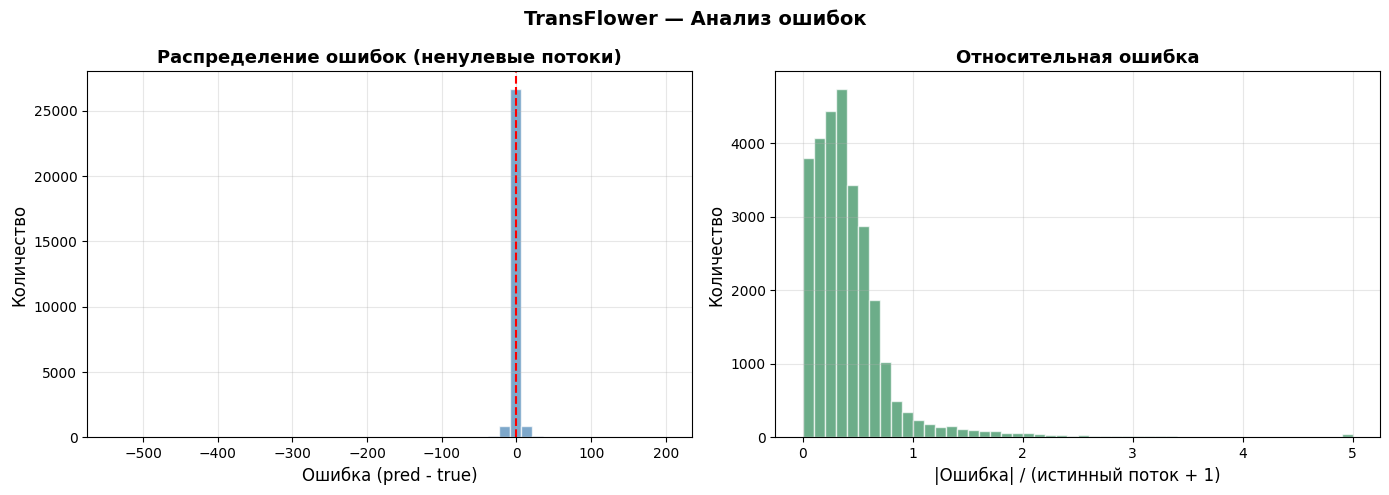

In [ ]:
# ── Распределение ошибок ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

errors = pred_test.ravel() - true_test.ravel()
mask   = true_test.ravel() > 0

ax = axes[0]
ax.hist(errors[mask], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Ошибка (pred - true)', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)
ax.set_title('Распределение ошибок (ненулевые потоки)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Относительная ошибка
rel_errors = np.abs(errors[mask]) / (true_test.ravel()[mask] + 1)
ax = axes[1]
ax.hist(np.clip(rel_errors, 0, 5), bins=50, color='seagreen', alpha=0.7, edgecolor='white')
ax.set_xlabel('|Ошибка| / (истинный поток + 1)', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)
ax.set_title('Относительная ошибка', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('TransFlower — Анализ ошибок', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Итоговая таблица метрик

In [ ]:
# Финальный отчёт
print("\n" + "=" * 55)
print(f"  ИТОГИ | Город: {SINGLE_CITY}")
print("=" * 55)
print(f"  Регионов:            {N}")
print(f"  Параметров модели:   {n_params:,}")
print(f"  Эпох обучено:        {len(history['train_loss'])}")
print(f"  Лучший val loss:     {best_val_loss:.4f}")
print()
print("  Метрики на тесте:")
for k, v in metrics.items():
    print(f"    {k:6s} = {v:.4f}")
print("=" * 55)